# QAOAにおけるXYミキサーを用いた交通流最適化
交通流最適化問題は、量子コンピューティングにおいて最も有名な最適化問題の1つです。

## 参考文献
Traffic flow optimization using a quantum annealer  
Florian Neukart, Gabriele Compostella, Christian Seidel, David von Dollen, Sheir Yarkoni, Bob Parney   
https://arxiv.org/abs/1708.01625

## 例
9つの交差点と12本の道路からなるネットワークを考えます。

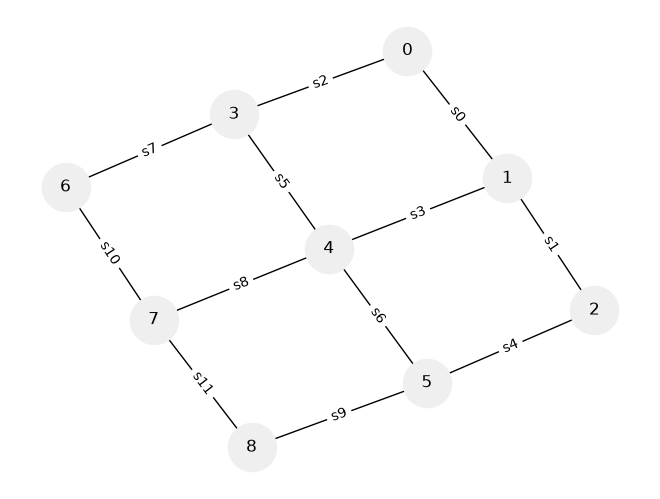

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from([i for i in range(9)])
G.add_edges_from([[0,1],(1,2),(0,3),(1,4),(2,5),(3,4),(4,5),(3,6),(4,7),(5,8),(6,7),(7,8)])
options = {'node_size': 1200,'with_labels':'True'}
pos = nx.spring_layout(G)
nx.draw(G, pos, **options, node_color='#efefef')

edge_labels={(0,1):'s0',(1,2):'s1',(0,3):'s2',(1,4):'s3',(2,5):'s4',(3,4):'s5',(4,5):'s6',(3,6):'s7',(4,7):'s8',(5,8):'s9',(6,7):'s10',(7,8):'s11'}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

## 2台の車とそれぞれ3通りの経路
ここで、点0から点8まで移動する2台の車を考えます。それぞれの車に対して3通りの経路を提案し、複数の車が同じ道路を通る場合はその道路の混雑度としてコストを数えることにします。そして、提案された各経路に対してQ0からQ5までの量子ビットを割り当てます。

車1の経路  
Q0 : s0,s3,s8,s11  
Q1 : s2,s7,s10,s11  
Q2 : s0,s1,s4,s9  

車2の経路  
Q3 : s0,s3,s8,s11  
Q4 : s2,s7,s10,s11  
Q5 : s0,s1,s4,s9  

## 混雑度の計算
混雑度は、提案された経路の中にその道路が含まれているかどうかによって決まります。s0からs11までの各道路の混雑度を計算し、それらを足し合わせることで全体の混雑度を求めることができます。例えば、s0は提案された経路のQ0、Q2、Q3、Q5に現れるため、そのコストは$(Q0+Q2+Q3+Q5)^2$となります。全体のコストは次の通りです。

$$
H = (Q0+Q2+Q3+Q5)^2 + (Q2+Q5)^2 + (Q1+Q4)^2 + (Q0+Q3)^2 + (Q2+Q5)^2 + (Q1*Q4)^2 + (Q0+Q3)^2 + (Q2+Q5)^2 + (Q1+Q4)^2 + (Q0+Q1+Q3+Q4)^2
$$


In [2]:
from blueqat.utils import qubo_bit as q

# Note: the new SDK's Expr (a sum of terms) no longer supports **2 directly
# (only a single Term does), and q(i) itself already returns an Expr; write
# each square as an explicit self-product instead.
hamiltonian = (q(0)+q(2)+q(3)+q(5))*(q(0)+q(2)+q(3)+q(5)) + (q(2)+q(5))*(q(2)+q(5)) + (q(1)+q(4))*(q(1)+q(4)) + (q(0)+q(3))*(q(0)+q(3)) + (q(2)+q(5))*(q(2)+q(5)) + (q(1)*q(4))*(q(1)*q(4)) + (q(0)+q(3))*(q(0)+q(3)) + (q(2)+q(5))*(q(2)+q(5)) + (q(1)+q(4))*(q(1)+q(4)) + (q(0)+q(1)+q(3)+q(4))*(q(0)+q(1)+q(3)+q(4))

## ハード制約
ここで守るべき制約が1つあります。それは、各車がちょうど1つの経路だけを選ぶという制約です。これはXYミキサーを使うことで簡単に解決できます。XYミキサーは、問題をどのように探索するかを決めるハミルトニアンであり、01と10の状態ベクトルを入れ替えるようにして探索が行われます。ここでは、車1と車2はそれぞれ3つの経路のうち1つだけを選ぶため、Q0、Q1、Q2のうちどれか1つの量子ビットだけが1になり、残りは0になります。同様に、Q3、Q4、Q5のうちどれか1つだけが1になります。この状態を維持するために、2optと呼ばれる量子ビットを交換する仕組みが使われます。初期状態としては、制約を満たす任意の状態を選びます。

## Quantum Alternating Operator Ansatz

In [3]:
from blueqat import Circuit
from blueqat.utils import X, Y, Vqe, QaoaAnsatz
import time

step = 4

#mixer and init state
mixer = 0.5*X[0]*X[1] + 0.5*Y[0]*Y[1] + 0.5*X[1]*X[2] + 0.5*Y[1]*Y[2] + 0.5*X[2]*X[0] + 0.5*Y[2]*Y[0]
mixer += 0.5*X[3]*X[4] + 0.5*Y[3]*Y[4] + 0.5*X[4]*X[5] + 0.5*Y[4]*Y[5] + 0.5*X[5]*X[3] + 0.5*Y[5]*Y[3]
init = Circuit(6).x[0].x[3]

start = time.time()
ansatz = QaoaAnsatz(hamiltonian, step, init, mixer)
result = Vqe(ansatz).run()
b = result.circuit.run(shots=10)
sample = b.most_common(1)[0][0]

print(time.time()-start)
print("sample:"+ str(sample))

/Users/yuichirominato/blueqatSDK/.claude/worktrees/determined-mahavira-bf713e/blueqat/utils.py:399: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  total_matrix = torch.sparse_coo_tensor(torch.empty((2, 0), dtype=torch.int64, device=device), torch.empty(0, dtype=torch.complex128, device=device), (dim, dim))


121.57405424118042
sample:010100


最も混雑度が低い組み合わせは、Q2とQ4、またはQ1とQ5のどちらかです。これらは同じ道路を通らないためです。QAOAはヒューリスティックな最適化手法であるため、実行のたびにこの大域的最適解にたどり着くこともあれば、混雑度がやや高い別の有効な(制約を満たす)組み合わせに落ち着くこともあります。